# PDOS vs. Al content (Al10 / Al30 / Al50 / Al70)

Multi-origin-averaged PDOS post-processing from LAMMPS `compute vacf` window
files, generalized to compare **composition** instead of temperature.

Expects window files named like:
```
Al10-300K-partial-vacf-win1.dat, Al10-300K-partial-vacf-win2.dat, ...
Al30-300K-partial-vacf-win1.dat, ...
Al50-300K-partial-vacf-win1.dat, ...
Al70-300K-partial-vacf-win1.dat, ...
```
as written by the updated `PDOS_mod.in` (one LAMMPS run per composition,
same temperature). Each window file is a single-origin VACF in the same
6-column format (timestep + 5 element columns, Fe/Ni/Cr/Co/Al order).

In [11]:
import glob
import re
import numpy as np
import pandas as pd
from scipy.fft import dct
from scipy.ndimage import gaussian_filter1d

_trapz = getattr(np, "trapezoid", None) or np.trapz  # numpy >=2.0 renamed trapz -> trapezoid

# ------------------------ USER SETTINGS ------------------------------
dt_ps        = 0.001      # LAMMPS timestep (ps)
elements     = ["Fe", "Ni", "Cr", "Co", "Al"]   # must match pair_coeff order in PDOS_mod.in

# Temperature the composition sweep was run at (fixed across all compositions).
# Change this if you ran the sweep at a different T.
T_LABEL      = "300K"

# Compositions to compare -- must match the ALPCT label used when running
# PDOS_mod.in (e.g. -var ALPCT Al10), which in turn sets the output filename
# prefix "<ALPCT>-<T>K-partial-vacf-winN.dat".
compositions = ["Al10", "Al30", "Al50", "Al70"]

# Atomic fractions per composition. Adjust to your ACTUAL measured/nominal
# composition -- this default assumes the remaining (100 - %Al) is split
# equally among Fe, Co, Cr, Ni, i.e. (FeCoCrNi)_(100-x) Al_x.
def atomic_fractions_for(comp_label):
    al_pct = int(re.search(r"Al(\d+)", comp_label).group(1))
    al_frac = al_pct / 100.0
    other_frac = (1.0 - al_frac) / 4.0
    return {"Fe": other_frac, "Ni": other_frac, "Cr": other_frac,
            "Co": other_frac, "Al": al_frac}

zero_pad_factor     = 8
window_type         = "exponential"   # "hann" or "exponential"
exp_decay_ps        = 3.0
smoothing_sigma_THz = 0.15
freq_max_THz        = 15.0
output_csv          = "pdos_by_composition_combined.csv"

In [12]:
def read_vacf_window(path):
    """Returns dict element -> 1D vacf array (length = steps in that window)."""
    with open(path, "r") as f:
        lines = f.readlines()
    rows = []
    for line in lines:
        if line.startswith("#"):
            continue
        parts = line.split()
        if len(parts) == 6:
            rows.append([float(x) for x in parts])
    data = np.array(rows)
    return {el: data[:, i + 1] for i, el in enumerate(elements)}


def multi_origin_average(comp_label, t_label):
    """Average every window file for this composition -> one VACF per element."""
    win_files = sorted(
        glob.glob(f"{comp_label}-{t_label}-partial-vacf-win*.dat"),
        key=lambda x: int(re.search(r"win(\d+)", x).group(1)),
    )
    if not win_files:
        raise ValueError(f"No window files found for {comp_label} at {t_label}")
    per_window = [read_vacf_window(f) for f in win_files]
    min_len = min(len(w[elements[0]]) for w in per_window)  # in case a window is short
    averaged = {}
    for el in elements:
        stacked = np.stack([w[el][:min_len] for w in per_window])
        vacf = stacked.mean(axis=0)
        averaged[el] = vacf / vacf[0]   # normalize VACF(0) = 1
    print(f"  {comp_label} @ {t_label}: averaged {len(win_files)} windows, {min_len} steps each")
    return averaged


def apply_window(vacf, dt_ps):
    n = len(vacf)
    if window_type == "hann":
        w = np.hanning(2 * n)[n:]
    else:
        t = np.arange(n) * dt_ps
        w = np.exp(-t / exp_decay_ps)
    return vacf * w


def vacf_to_pdos(vacf, dt_ps, n_pad):
    spectrum = dct(vacf, type=1, n=n_pad)
    spectrum = np.clip(spectrum, 0, None)
    freqs_thz = np.fft.rfftfreq(2 * (n_pad - 1), d=dt_ps * 1e-12) / 1e12
    freqs_thz = freqs_thz[: len(spectrum)]
    return freqs_thz, spectrum


def process_composition(comp_label, t_label):
    print(f"Processing {comp_label}...")
    vacf_by_element = multi_origin_average(comp_label, t_label)
    fracs = atomic_fractions_for(comp_label)

    n_pad = None
    total_pdos = None
    freqs = None

    for el in elements:
        vacf_w = apply_window(vacf_by_element[el], dt_ps)
        if n_pad is None:
            n_pad = zero_pad_factor * len(vacf_w)
        f_thz, spec = vacf_to_pdos(vacf_w, dt_ps, n_pad)
        if total_pdos is None:
            total_pdos = np.zeros_like(spec)
            freqs = f_thz
        total_pdos += spec * fracs[el]

    total_pdos = total_pdos / _trapz(total_pdos, freqs)
    freq_resolution = freqs[1] - freqs[0]
    sigma_idx = smoothing_sigma_THz / freq_resolution
    total_pdos_smoothed = gaussian_filter1d(total_pdos, sigma=sigma_idx)
    return freqs, total_pdos_smoothed

In [14]:
def main():
    win_files = glob.glob(f"*-{T_LABEL}-partial-vacf-win*.dat")
    if not win_files:
        raise ValueError(
            f"No window files found for T_LABEL='{T_LABEL}'. "
            f"Expected e.g. 'Al10-{T_LABEL}-partial-vacf-win1.dat'."
        )

    found_comps = sorted(
        set(re.search(r"^(Al\d+)-", f).group(1) for f in win_files
            if re.search(r"^(Al\d+)-", f)),
        key=lambda x: int(re.search(r"Al(\d+)", x).group(1)),
    )
    missing = [c for c in compositions if c not in found_comps]
    if missing:
        print(f"Warning: no files found for {missing}, skipping them.")
    comps_to_run = [c for c in compositions if c in found_comps]
    print(f"Found compositions: {comps_to_run}\n")

    combined = {}
    shared_freqs = None
    for comp_label in comps_to_run:
        freqs, pdos = process_composition(comp_label, T_LABEL)
        if shared_freqs is None:
            shared_freqs = freqs
            combined["Frequency_THz"] = shared_freqs
        combined[f"Smoothed_{comp_label}"] = np.interp(shared_freqs, freqs, pdos)

    df = pd.DataFrame(combined)
    df = df[df["Frequency_THz"] <= freq_max_THz].reset_index(drop=True)
    df.to_csv(output_csv, index=False)
    print(f"\nData saved to '{output_csv}'")
    return df

In [19]:
def plot_pdos(df, save_path="pdos_composition_comparison.png"):
    """Plot PDOS vs frequency, one line per Al composition, styled like a
    publication figure (single panel, clean legend, no per-curve markers)."""
    import matplotlib.pyplot as plt

    comp_cols = [c for c in df.columns if c.startswith("Smoothed_")]
    # sort legend by %Al, not string order
    comp_cols.sort(key=lambda c: int(re.search(r"Al(\d+)", c).group(1)))

    fig, ax = plt.subplots(figsize=(7, 5))
    for col in comp_cols:
        label = re.search(r"(Al\d+)", col).group(1)
        pct = int(re.search(r"Al(\d+)", col).group(1))
        ax.plot(df["Frequency_THz"], df[col], linewidth=1.6, label=f"{pct}% Al")

    ax.set_xlabel(r"$\omega$ (THz)", fontsize=12)
    ax.set_ylabel("PDOS", fontsize=12)
    ax.set_xlim(0, df["Frequency_THz"].max())
    ax.set_ylim(bottom=0)
    ax.legend(title="Composition", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    plt.show()
    print(f"Figure saved to '{save_path}'")

Found compositions: ['Al10', 'Al30', 'Al50', 'Al70']

Processing Al10...
  Al10 @ 300K: averaged 15 windows, 10001 steps each
Processing Al30...
  Al30 @ 300K: averaged 15 windows, 10001 steps each
Processing Al50...
  Al50 @ 300K: averaged 15 windows, 10001 steps each
Processing Al70...
  Al70 @ 300K: averaged 15 windows, 10001 steps each

Data saved to 'pdos_by_composition_combined.csv'


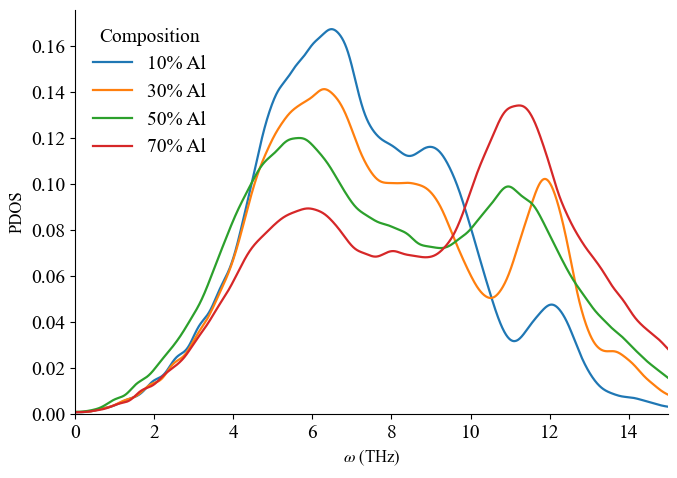

Figure saved to 'pdos_composition_comparison.png'


In [20]:
pdos_df = main()
plot_pdos(pdos_df)